#### Introduction

The goal of the project is to build a predictive model that will determine whether a mushroom is edible based on its characteristics such as cap shape, odor, gill size and others.

The dataset used in this project originally comes from UCI Machine Learning Repository (https://www.kaggle.com/datasets/uciml/mushroom-classification?select=mushrooms.csv) and contains 8124 records (mushroom samples) each described by 22 categorical features. As all features in the dataset are non-numeric, the project incorporates a preprocessing pipeline that applies One-Hot Encoding to convert categorical attributes into a numerical format suitable for ML algorithms. 

After exploring data through couple visualizations and correlation analysis, a Random Forest classifier is trained. The model is then evaluated on the test set and feature importance analysis is performed to understand, which mushroom traits contribute the most to the prediction.

The project demonstrates the full lifecycle of a supervised classification task - from data exploration and preprocessing to model training, evaluation, and interpretation.

#### Imports

In [35]:
import pandas as pd

#### Reading Data

In [ ]:
df = pd.read_csv('mushrooms.csv')



(8124, 23)

#### Initial Exploration

In [30]:
df.shape

(8124, 23)

In [29]:
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [19]:
df.tail()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [31]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [32]:
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

#### Preprocessing

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X = df.drop('class', axis=1) # Features
y = df['class'] # Target variable

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), X.columns)
    ]
)


#### Splitting the data

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Plots

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

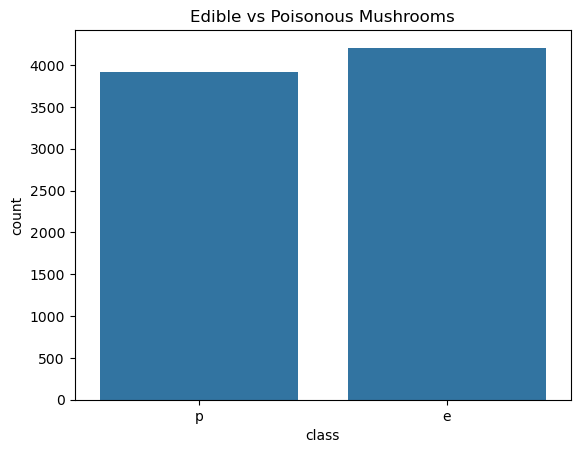

In [ ]:
# Distribution of classes

sns.countplot(data=df, x='class')
plt.title('Edible vs Poisonous Mushrooms')
plt.show()

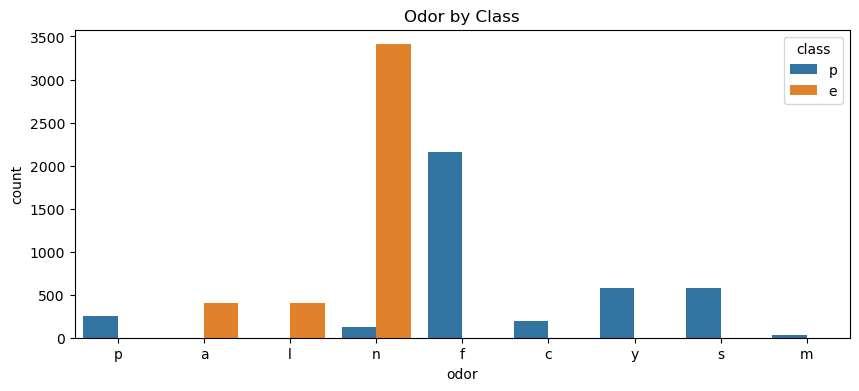

In [38]:
# Odor by class
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='odor', hue='class')
plt.title("Odor by Class")
plt.show()


C:\Users\bedna\AppData\Local\Temp\ipykernel_7556\2892330795.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")


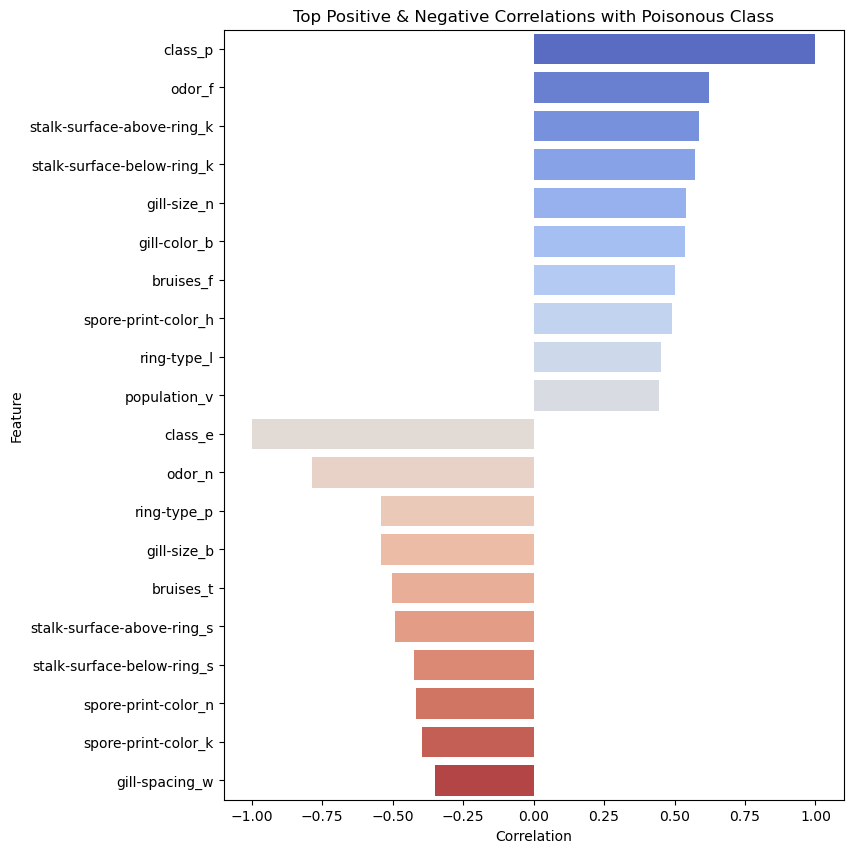

In [ ]:
# Correlation Plot

encoded_df = pd.get_dummies(df, drop_first=False)

corr = encoded_df.corr()['class_p']

top_pos = corr.sort_values(ascending=False).head(10)
top_neg = corr.sort_values().head(10)

top_corr = pd.concat([top_pos, top_neg])

plt.figure(figsize=(8, 10))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")
plt.title("Top Positive & Negative Correlations with Poisonous Class")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()


#### Buliding the model

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object'))])),
                ('clf',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

#### Model Evaluation

In [48]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       843
           p       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



#### Feature Importance

C:\Users\bedna\AppData\Local\Temp\ipykernel_7556\2944065399.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


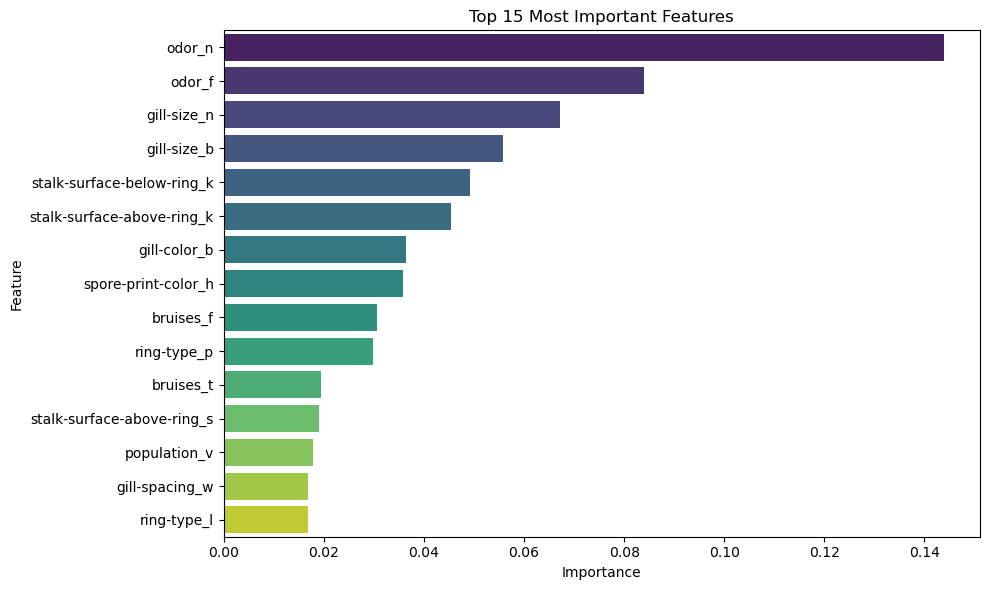

In [ ]:
import numpy as np

ohe = model.named_steps['preprocess'].named_transformers_['cat']
feature_names = ohe.get_feature_names_out(X.columns)

importances = model.named_steps['clf'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values('importance', ascending=False)

top_n = 15 

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp.head(top_n),
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title(f"Top {top_n} Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()




#### Results and Interpretation

The Random Forest classifier achieved perfect performance on the test set, reaching an accuracy of 1.0 with precision, recall, and F1‑scores of 1.00 for both edible and poisonous classes. This indicates that the model was able to fully separate the two classes based on the provided mushroom characteristics. The balanced performance across both labels suggests that the model generalizes well and does not favor one class over the other.

Feature importance analysis shows that odor is by far the strongest predictor, with categories such as foul and none carrying the highest importance scores. Additional influential features include gill size, stalk surface characteristics, gill color, and spore‑print color. These results align with the earlier correlation analysis and confirm that certain mushroom traits carry extremely strong signals about edibility.

Overall, the model not only performs exceptionally well but also provides interpretable insights into which biological features distinguish poisonous mushrooms from edible ones.